In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('StudentsPerformance.csv')

In [3]:
df.shape

(1000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


using np seed you get the same random values every time
42 is just choice of integer

In [8]:
np.random.seed(42)
df['Science Score']=np.random.randint(-20,130,size=len(df))

In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Science Score
0,female,group B,bachelor's degree,standard,none,72,72,74,82
1,female,group C,some college,standard,completed,69,90,88,72
2,female,group B,master's degree,standard,none,90,95,93,-6
3,male,group A,associate's degree,free/reduced,none,47,57,44,86
4,male,group C,some college,standard,none,76,78,75,51


label-based selection
df.sample(frac=0.1) randomly selects few indexes from the column 

In [10]:
df.loc[df.sample(frac=0.1).index,"Science Score"]=np.nan

In [11]:
df.isnull().sum()

gender                           0
race/ethnicity                   0
parental level of education      0
lunch                            0
test preparation course          0
math score                       0
reading score                    0
writing score                    0
Science Score                  100
dtype: int64

ffill is forward fill 

it fills the missing  value with previous valid value

eg
80
nan
nan
90

after forward fill
80
80
80
90

bfill is backward fill
it fills the missing value with next valid value


eg
nan
nan 
80
90

after backward fill
80
80
80
90




In [12]:
df["Science Score"]=df["Science Score"].ffill()
df["Science Score"]=df["Science Score"].bfill()

In [13]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
Science Score                  0
dtype: int64

In [14]:
int((df["Science Score"]<0).sum()),int((df["Science Score"]>100).sum())

(128, 203)

In [15]:
med=df["Science Score"].median()
df["Science Score"]=df["Science Score"].where(df["Science Score"].between(0,100),med)

In [16]:
int((df["Science Score"]<0).sum()),int((df["Science Score"]>100).sum())

(0, 0)

In [17]:
df["CGPA"]=(
    df['Science Score']
    +df['math score']
    +df['reading score']
    +df['writing score'])/400 *10

In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Science Score,CGPA
0,female,group B,bachelor's degree,standard,none,72,72,74,82.0,7.500
1,female,group C,some college,standard,completed,69,90,88,72.0,7.975
2,female,group B,master's degree,standard,none,90,95,93,54.0,8.300
3,male,group A,associate's degree,free/reduced,none,47,57,44,86.0,5.850
4,male,group C,some college,standard,none,76,78,75,51.0,7.000


An outlier is a data point that is much smaller or much larger than most of the other values in a dataset.

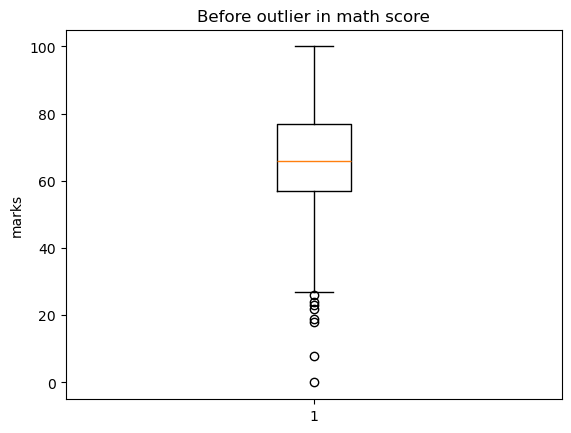

In [19]:
plt.boxplot(df["math score"])
plt.title("Before outlier in math score")
plt.ylabel("marks")
plt.show()

IQR stands for Interquartile Range.

So IQR tells us how spread out the central part of the data is.It measures the spread of the middle 50% of your data.

IQR=Q3-Q1

LOWER BOUND=Q1-1.5*IQR
UPPER BOUND=Q3+1.5*IQR

OTHER METHODS TO DETECT AND REMOVE OUTLIERS ARE 
ZSCORE
VISUALLY USING BOXPLOT 
USING DOMAIN KNOWLEDGE
USING CAPPING METHOD->FIXING LOWER AND UPPER BOUNDARY

In [20]:
Q1=df["math score"].quantile(0.25)
Q3=df["math score"].quantile(0.75)

In [21]:
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df["math score"]=df["math score"].where(df["math score"]>=lower_bound,lower_bound)
df["math score"]=df["math score"].where(df["math score"]<=upper_bound,upper_bound)

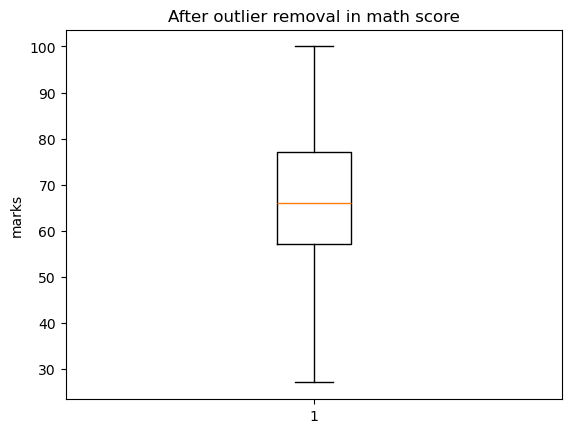

In [22]:
plt.boxplot(df["math score"])
plt.title("After outlier removal in math score")
plt.ylabel("marks")
plt.show()

In [23]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

LABEL ENCODER CONVERTS CATEGORICAL text values  IN NUMERICAL data

it has two parts 
fit->learns about unique values
transform->converts the unique values into numbers

we need label encoder ml algo dont understand string they understand numbers

if more than two categories then
one hot encoding

In [24]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["gender"]=le.fit_transform(df["gender"])
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Science Score,CGPA
0,0,group B,bachelor's degree,standard,none,72,72,74,82.0,7.500
1,0,group C,some college,standard,completed,69,90,88,72.0,7.975
2,0,group B,master's degree,standard,none,90,95,93,54.0,8.300
3,1,group A,associate's degree,free/reduced,none,47,57,44,86.0,5.850
4,1,group C,some college,standard,none,76,78,75,51.0,7.000
...,...,...,...,...,...,...,...,...,...,...
995,0,group E,master's degree,standard,completed,88,99,95,50.0,8.300
996,1,group C,high school,free/reduced,none,62,55,55,54.0,5.650
997,0,group C,high school,free/reduced,completed,59,71,65,41.0,5.900
998,0,group D,some college,standard,completed,68,78,77,11.0,5.850


In [25]:
df['gender'].value_counts()

gender
0    518
1    482
Name: count, dtype: int64

standard scaler is to be used when data is normally distributed 
minmax when we need data in bounded range of 0,1 or when data is not normally distributed 

normally distributed data means most data is in the bell shape curve near the mean 
and fewer values are the either side of it 

classic ml ->standard scaler
deep learning/bounded ->minmax

In [26]:
df['math_scaled']=(df['math score']-df['math score'].min())/(df['math score'].max()-df['math score'].min())

histogram is used for continuous data
bar chart is used for categorical data

A bin is a range (group) of values used to organize numerical data in a histogram.

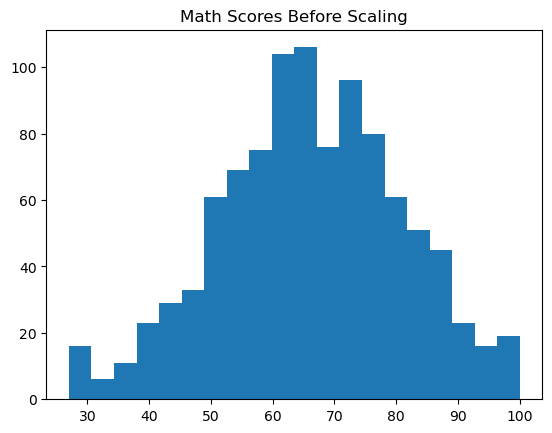

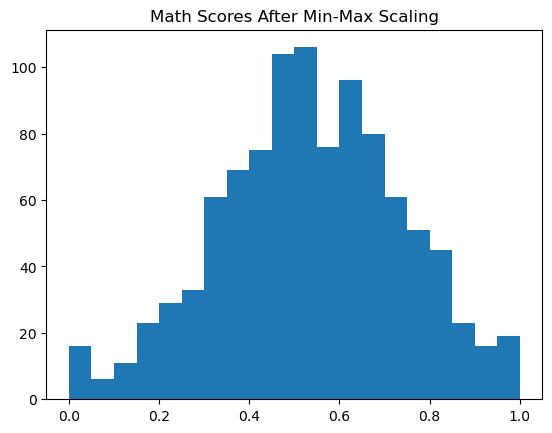

In [27]:
plt.hist(df["math score"], bins=20)
plt.title("Math Scores Before Scaling")
plt.show()

plt.hist(df["math_scaled"], bins=20)
plt.title("Math Scores After Min-Max Scaling")
plt.show()


Skewness tells us how much a dataset is asymmetrical (not balanced) around its center.

It shows whether data is leaning more to the left or to the right.

If data is perfectly balanced like a normal distribution, skewness is close to 0.



Measures of Central Tendency

These are values that represent the center or typical value of a dataset.

Main measures:

Mean → average
Median → middle value
Mode → most frequent value

These help answer:

“Where is the center of the data?”
1. Mean

Formula:

Mean=
n
∑X
	​


Mean=
n
∑X
	​


Example:

[10, 20, 30]
Mean = 20
2. Median

The middle value after sorting.

Example:

[10, 20, 30]
Median = 20
3. Mode

The most frequently occurring value.

Example:

[10, 20, 20, 30]
Mode = 20
Effect of Skewness on Mean, Median, Mode
A. Normal Distribution (No skew)

Everything is balanced.

Mean=Median=Mode

Mean=Median=Mode

B. Positive Skew (Right-skewed)

Large values on the right pull the mean upward.

Relationship:

Mode<Median<Mean

Mode<Median<Mean

Example:

Income distribution

few very rich people increase mean
C. Negative Skew (Left-skewed)

Small values on the left pull the mean downward.

Relationship:

Mean<Median<Mode

Mean<Median<Mode

Example:

Easy exam marks

most students score high
few score very low
Quick Memory Trick
Positive skew
Mean goes to the right
Negative skew
Mean goes to the left

Because mean is most affected by extreme values.

Opposite of Central Tendency

You are referring to:

Measures of Dispersion (or Spread)

These tell us:

“How spread out is the data?”

instead of center.

Main measures:

Range
Variance
Standard Deviation
IQR (Interquartile Range)

In [28]:
data=df.select_dtypes(include=np.number).skew()

In [29]:
data

gender           0.072155
math score      -0.148833
reading score   -0.259105
writing score   -0.289444
Science Score   -0.135218
CGPA            -0.168457
math_scaled     -0.148833
dtype: float64

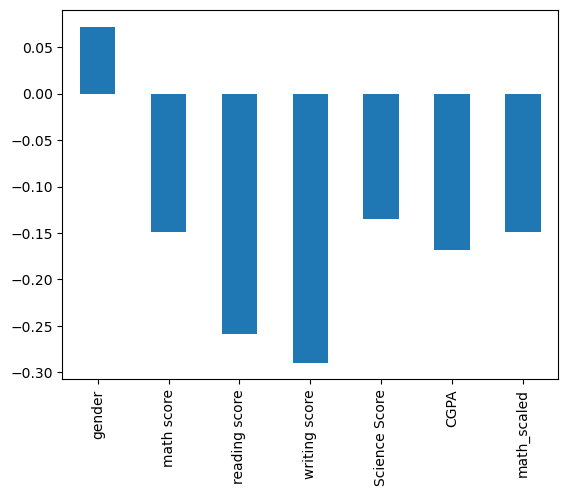

In [30]:
data.plot(kind="bar")
plt.show()

What is Kurtosis?
Kurtosis tells us how much the data has:


heavy tails (more extreme values / outliers)


sharp peak or flat peak


It helps describe the shape of the distribution, especially compared to a normal distribution.
6
It mainly answers:
“How extreme are the tails of the data?”
not just whether it is left/right skewed.

Simple idea
Two datasets can have same mean and same standard deviation,
but one may have:


more outliers


sharper peak


That difference is explained by kurtosis.

Normal Distribution
A normal distribution has:
Kurtosis = 3
(when using standard definition)
or
Excess Kurtosis = 0
(in many libraries like pandas)

Types of Kurtosis

1. Mesokurtic
Normal distribution


medium peak


normal tails


Example:
Kurtosis ≈ 0   (excess kurtosis)

2. Leptokurtic
High kurtosis


sharper peak


heavier tails


more outliers


Example:
Kurtosis > 0
More extreme values exist.

3. Platykurtic
Low kurtosis


flatter peak


lighter tails


fewer outliers


Example:
Kurtosis < 0
Less extreme values.